# Demo 2: RAG, Function Calling, & MCP

Build a Retrieval-Augmented Generation pipeline that grounds LLM responses in actual clinical guidelines, wire up function calling so the model can take actions, then see how MCP standardizes tool integration.

## Setup

In [1]:
%pip install -q sentence-transformers chromadb chroma-mcp openai openai-agents python-dotenv mcp scikit-learn matplotlib numpy

Note: you may need to restart the kernel to use updated packages.


In [2]:
import os
import json
import warnings
import numpy as np
from dotenv import load_dotenv

load_dotenv()

# Suppress noisy library warnings at the source:
# - HuggingFace progress bars and tokenizer fork warnings
# - transformers informational logging
# - chromadb resource tracker cleanup noise
os.environ["HF_HUB_DISABLE_PROGRESS_BARS"] = "1"
os.environ["TOKENIZERS_PARALLELISM"] = "false"
warnings.filterwarnings("ignore", message=".*resource_tracker.*")
warnings.filterwarnings("ignore", category=FutureWarning, module="transformers")

import transformers
transformers.logging.set_verbosity_error()

from sentence_transformers import SentenceTransformer
import chromadb
from openai import OpenAI, AsyncOpenAI
from agents import Agent, Runner, ModelSettings, function_tool, set_tracing_disabled
from agents.models.openai_chatcompletions import OpenAIChatCompletionsModel
from agents.mcp import MCPServerStdio

set_tracing_disabled(True)

# OpenRouter provides a unified API for many models behind an OpenAI-compatible
# endpoint. We point the standard OpenAI client at it by swapping base_url.
if os.environ.get("OPENROUTER_API_KEY"):
    client = OpenAI(
        api_key=os.environ["OPENROUTER_API_KEY"],
        base_url="https://openrouter.ai/api/v1",
    )
    MODEL = "openai/gpt-4o-mini"
    # Async client for the Agents SDK
    agents_client = AsyncOpenAI(
        api_key=os.environ["OPENROUTER_API_KEY"],
        base_url="https://openrouter.ai/api/v1",
    )
    AGENTS_MODEL = OpenAIChatCompletionsModel(model="openai/gpt-4o-mini", openai_client=agents_client)
elif os.environ.get("OPENAI_API_KEY"):
    client = OpenAI()
    MODEL = "gpt-4o-mini"
    agents_client = AsyncOpenAI()
    AGENTS_MODEL = OpenAIChatCompletionsModel(model="gpt-4o-mini", openai_client=agents_client)
else:
    raise ValueError("Set OPENROUTER_API_KEY or OPENAI_API_KEY in .env")

print(f"Using model: {MODEL}")

Using model: openai/gpt-4o-mini


## Section 1: Clinical Knowledge Base

Synthetic clinical guideline chunks — the kind of documents a hospital might want an LLM to reference when answering clinical questions. Each chunk has an id, the text content, and a source attribution. In production these would come from splitting real guideline PDFs into overlapping passages.

In [3]:
clinical_knowledge = [
    {
        "id": "hypertension_1",
        "text": "Stage 1 hypertension is defined as systolic blood pressure 130-139 mmHg or diastolic 80-89 mmHg. Initial treatment includes lifestyle modifications: weight loss, DASH diet, sodium restriction (<2300mg/day), regular exercise (150 min/week moderate intensity).",
        "source": "JNC8 Guidelines"
    },
    {
        "id": "hypertension_2",
        "text": "First-line antihypertensive medications include thiazide diuretics, ACE inhibitors, ARBs, and calcium channel blockers. Choice depends on comorbidities: ACE inhibitors or ARBs preferred in diabetes and chronic kidney disease.",
        "source": "JNC8 Guidelines"
    },
    {
        "id": "diabetes_1",
        "text": "Type 2 diabetes is diagnosed with fasting glucose ≥126 mg/dL, HbA1c ≥6.5%, or 2-hour glucose ≥200 mg/dL during OGTT. Metformin is first-line therapy unless contraindicated. Target HbA1c <7% for most adults.",
        "source": "ADA Standards of Care"
    },
    {
        "id": "diabetes_2",
        "text": "For patients with type 2 diabetes and cardiovascular disease, SGLT2 inhibitors or GLP-1 receptor agonists with proven cardiovascular benefit are recommended regardless of HbA1c. Examples: empagliflozin, liraglutide.",
        "source": "ADA Standards of Care"
    },
    {
        "id": "chest_pain_1",
        "text": "Acute chest pain evaluation: HEART score assesses History, ECG, Age, Risk factors, and Troponin. Score 0-3 is low risk (discharge with follow-up), 4-6 is intermediate (admit for observation), 7-10 is high risk (early invasive strategy).",
        "source": "AHA Chest Pain Guidelines"
    },
    {
        "id": "chest_pain_2",
        "text": "STEMI diagnosis requires ST elevation ≥1mm in 2 contiguous leads or new LBBB with symptoms. Door-to-balloon time goal <90 minutes for primary PCI. If PCI not available within 120 minutes, fibrinolysis within 30 minutes.",
        "source": "AHA Chest Pain Guidelines"
    },
]

print(f"{len(clinical_knowledge)} guideline chunks loaded")
for doc in clinical_knowledge:
    print(f"  [{doc['source']}] {doc['text'][:60]}...")

6 guideline chunks loaded
  [JNC8 Guidelines] Stage 1 hypertension is defined as systolic blood pressure 1...
  [JNC8 Guidelines] First-line antihypertensive medications include thiazide diu...
  [ADA Standards of Care] Type 2 diabetes is diagnosed with fasting glucose ≥126 mg/dL...
  [ADA Standards of Care] For patients with type 2 diabetes and cardiovascular disease...
  [AHA Chest Pain Guidelines] Acute chest pain evaluation: HEART score assesses History, E...
  [AHA Chest Pain Guidelines] STEMI diagnosis requires ST elevation ≥1mm in 2 contiguous l...


## Section 2: Embedding & ChromaDB Indexing

An embedding is a fixed-length numeric vector that captures the *meaning* of a text chunk — similar documents end up near each other in vector space. ChromaDB is an in-memory vector database: we encode each chunk into an embedding, store them, and later retrieve the closest matches to a query.

In [4]:
# all-MiniLM-L6-v2: a small (22M param) model that maps text → 384-dim vectors.
# Runs locally on CPU — no API call needed for embedding.
embedding_model = SentenceTransformer("all-MiniLM-L6-v2")

# ChromaDB stores vectors in-memory. In production you'd use a persistent store.
chroma_client = chromadb.Client()
collection = chroma_client.create_collection(
    name="clinical_guidelines",
    metadata={"description": "Clinical practice guidelines"},
)

# Prepare parallel lists: ChromaDB expects documents, ids, metadata, and embeddings
# to line up by index.
documents = [doc["text"] for doc in clinical_knowledge]
ids = [doc["id"] for doc in clinical_knowledge]
metadatas = [{"source": doc["source"]} for doc in clinical_knowledge]

# encode() runs the text through the model and returns a numpy array of shape
# (n_documents, 384). We convert to list for ChromaDB.
embeddings = embedding_model.encode(documents).tolist()

collection.add(
    documents=documents,
    ids=ids,
    metadatas=metadatas,
    embeddings=embeddings,
)

print(f"Indexed {collection.count()} chunks in ChromaDB")
print(f"Embedding dimension: {len(embeddings[0])}")
print(f"\nFirst embedding (truncated): [{', '.join(f'{x:.4f}' for x in embeddings[0][:8])}, ...]")

Indexed 6 chunks in ChromaDB
Embedding dimension: 384

First embedding (truncated): [-0.0254, 0.0779, -0.0609, -0.0790, -0.0819, -0.0206, -0.0450, -0.0067, ...]


Each chunk is now a 384-dimensional vector. Chunks about similar topics should be close together in that space — let's verify with a similarity heatmap:

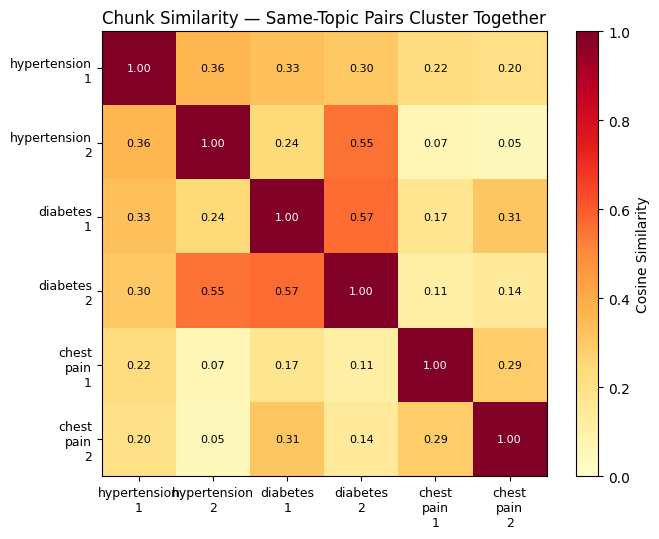

In [5]:
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity

# Cosine similarity: 1.0 = identical meaning, 0.0 = unrelated
sim_matrix = cosine_similarity(embeddings)
labels = [doc["id"].replace("_", "\n") for doc in clinical_knowledge]

fig, ax = plt.subplots(figsize=(7, 5.5))
im = ax.imshow(sim_matrix, cmap="YlOrRd", vmin=0, vmax=1)
ax.set_xticks(range(len(labels)))
ax.set_yticks(range(len(labels)))
ax.set_xticklabels(labels, fontsize=9)
ax.set_yticklabels(labels, fontsize=9)

for i in range(len(labels)):
    for j in range(len(labels)):
        ax.text(j, i, f"{sim_matrix[i][j]:.2f}", ha="center", va="center", fontsize=8,
                color="white" if sim_matrix[i][j] > 0.6 else "black")

fig.colorbar(im, ax=ax, label="Cosine Similarity")
ax.set_title("Chunk Similarity — Same-Topic Pairs Cluster Together")
plt.tight_layout()
plt.show()

The hypertension chunks are most similar to each other, the diabetes chunks cluster, and the chest pain chunks cluster. This is what makes retrieval work — a question about hypertension will land near the hypertension chunks in vector space.

## Section 3: RAG via chroma-mcp

We just built a ChromaDB collection manually — embedding, indexing, querying all in our code. But ChromaDB provides an **MCP server** (`chroma-mcp`) that exposes all of this as standardized tools. An Agent can create collections, add documents, and query them through MCP — no custom retrieval code needed.

The key insight: RAG is just an agent with a vector search tool. The "retrieve-augment-generate" loop happens naturally when the agent calls the search tool and uses the results to answer.

In [6]:
import sys, tempfile
from pathlib import Path
from mcp import ClientSession, StdioServerParameters
from mcp.client.stdio import stdio_client

# chroma-mcp runs as a subprocess with persistent local storage — no cloud, no API keys
chroma_cmd = str(Path(sys.executable).parent / "chroma-mcp")
chroma_data_dir = tempfile.mkdtemp()

# Seed the vector DB: create collection + add our clinical guideline chunks.
# We do this at the MCP protocol level so the data is available when the Agent connects.
server_params = StdioServerParameters(
    command=chroma_cmd,
    args=["--client-type", "persistent", "--data-dir", chroma_data_dir],
)

async with stdio_client(server_params) as (read_stream, write_stream):
    async with ClientSession(read_stream, write_stream) as session:
        await session.initialize()

        await session.call_tool("chroma_create_collection", {
            "collection_name": "clinical_guidelines",
        })

        await session.call_tool("chroma_add_documents", {
            "collection_name": "clinical_guidelines",
            "documents": [doc["text"] for doc in clinical_knowledge],
            "ids": [doc["id"] for doc in clinical_knowledge],
            "metadatas": [{"source": doc["source"]} for doc in clinical_knowledge],
        })

print(f"Seeded {len(clinical_knowledge)} chunks into chroma-mcp (persistent @ {chroma_data_dir})")

Seeded 6 chunks into chroma-mcp (persistent @ /var/folders/43/0jfkbfr53g1_nbv1ymsqgfl40000gp/T/tmpvzchkq6f)


Now an Agent connects to the same chroma-mcp instance and uses `chroma_query_documents` to do RAG — the retrieve-augment-generate loop happens inside `Runner.run()`:

In [7]:
chroma_mcp = MCPServerStdio(
    params={
        "command": chroma_cmd,
        "args": ["--client-type", "persistent", "--data-dir", chroma_data_dir],
    },
    name="Clinical Guidelines DB",
)

rag_agent = Agent(
    name="RAG Assistant",
    instructions=(
        "You are a clinical assistant. When asked a question, use chroma_query_documents "
        "to search the clinical_guidelines collection for relevant context. "
        "Answer based ONLY on retrieved documents. Cite the source metadata."
    ),
    mcp_servers=[chroma_mcp],
    model=AGENTS_MODEL,
    model_settings=ModelSettings(temperature=0),
)

async with chroma_mcp:
    result = await Runner.run(rag_agent, input=(
        "What is the first-line treatment for hypertension in a patient with diabetes?"
    ))

# result.new_items shows every step the agent took — tool calls, outputs, final response
from agents.items import ToolCallItem, ToolCallOutputItem
tool_calls = [item for item in result.new_items if isinstance(item, ToolCallItem)]
for tc in tool_calls:
    call = tc.raw_item
    print(f"[Agent called: {call.name}({call.arguments[:80]}...)]")

print(f"\nQ: First-line treatment for hypertension in diabetic patients?\n")
print(f"A: {result.final_output}")

[Agent called: chroma_query_documents({"collection_name":"clinical_guidelines","query_texts":["first-line treatment fo...)]

Q: First-line treatment for hypertension in diabetic patients?

A: The first-line treatment for hypertension in a patient with diabetes includes thiazide diuretics, ACE inhibitors, ARBs (angiotensin receptor blockers), and calcium channel blockers. Among these, ACE inhibitors or ARBs are preferred, especially in patients with diabetes and chronic kidney disease (source: JNC8 Guidelines).


`result.new_items` exposes every step: the MCP tool calls the agent made, the retrieved documents it received back, and the final response. The agent discovered `chroma_query_documents` via MCP, searched the collection, and synthesized a grounded answer.

## Section 4: RAG vs Direct LLM

What happens when the model answers *without* retrieval tools? For well-known clinical facts the LLM may already know the answer — but for organization-specific protocols, recent guideline updates, or internal policy, the model has no choice but to guess or refuse.

In [8]:
# Same agent, same question — but with and without the vector DB tool
test_q = (
    "According to the AHA Chest Pain Guidelines, what HEART score threshold "
    "separates low-risk from intermediate-risk patients, and what is the recommended "
    "action for each risk category?"
)

# RAG: agent with chroma-mcp retrieval
async with chroma_mcp:
    rag_result = await Runner.run(rag_agent, input=test_q)

# Direct: agent without tools — just the LLM's training data
direct_agent = Agent(
    name="Direct Assistant",
    instructions="You are a clinical assistant. Be concise.",
    model=AGENTS_MODEL,
    model_settings=ModelSettings(temperature=0),
)
direct_result = await Runner.run(direct_agent, input=test_q)

print("RAG Response (grounded in our guidelines):")
print(rag_result.final_output)
print("\n" + "-" * 40 + "\n")
print("Direct LLM Response (from training data — may differ or hallucinate thresholds):")
print(direct_result.final_output)

RAG Response (grounded in our guidelines):
According to the AHA Chest Pain Guidelines, the HEART score thresholds are as follows:

- **Low Risk**: A HEART score of **0-3**. Recommended action is to **discharge the patient with follow-up**.
- **Intermediate Risk**: A HEART score of **4-6**. Recommended action is to **admit the patient for observation**.
- **High Risk**: A HEART score of **7-10**. Recommended action is to implement an **early invasive strategy** (source: AHA Chest Pain Guidelines).

----------------------------------------

Direct LLM Response (from training data — may differ or hallucinate thresholds):
According to the AHA Chest Pain Guidelines, a HEART score of 0-3 indicates low risk, while a score of 4-6 indicates intermediate risk. 

- **Low-risk (HEART score 0-3)**: Recommended action is to consider discharge with appropriate follow-up and reassurance.
- **Intermediate-risk (HEART score 4-6)**: Recommended action is to consider further diagnostic testing and observa

## Section 5: RAG with Citations

In clinical contexts, knowing *where* an answer came from is as important as the answer itself. The same agent, same MCP tools — just different instructions telling it to cite sources:

In [9]:
citing_agent = Agent(
    name="Citing RAG Assistant",
    instructions=(
        "You are a clinical assistant. When asked a question, use chroma_query_documents "
        "to search the clinical_guidelines collection. Include the metadatas field in your query. "
        "Answer based ONLY on retrieved documents. "
        "Cite each claim with the source from metadata, e.g. [JNC8 Guidelines]."
    ),
    mcp_servers=[chroma_mcp],
    model=AGENTS_MODEL,
    model_settings=ModelSettings(temperature=0),
)

async with chroma_mcp:
    result = await Runner.run(citing_agent, input=(
        "What medications are recommended for diabetic patients with heart disease?"
    ))

print(f"Q: Medications for diabetic patients with heart disease?\n")
print(f"A: {result.final_output}")

Q: Medications for diabetic patients with heart disease?

A: The recommended medications for diabetic patients with heart disease can be found in various clinical guidelines. Here are some key sources:

1. **ADA Standards of Care**: This guideline provides comprehensive recommendations for managing diabetes, including the use of specific medications that can benefit patients with concurrent heart disease.

2. **JNC8 Guidelines**: These guidelines focus on the management of hypertension, which is crucial for diabetic patients with heart disease, as controlling blood pressure is essential in this population.

3. **AHA Chest Pain Guidelines**: These guidelines address the management of chest pain in patients with heart disease, including those with diabetes, and may recommend specific treatments to alleviate symptoms and improve heart health.

For detailed medication recommendations, it is advisable to refer directly to these guidelines.


## Section 6: Function Calling — Letting the Model Use Tools

RAG retrieves documents. But what if the model needs to *do* something — look up a drug interaction, calculate a dose, check lab values? **Function calling** lets you define tools, pass them to the model, and let it decide when to invoke them.

The model never executes code — it generates a JSON object with the function name and arguments. The framework runs the actual function and feeds the result back.

### Defining Tools

The `@function_tool` decorator converts a Python function into a tool the agent can call. Type hints and docstrings become the JSON schema the model sees — no manual schema definition needed.

In [10]:
# Simulated drug interaction database — in production this would query
# a real pharmacy database (e.g., DrugBank, First Databank)
INTERACTION_DB = {
    ("metformin", "contrast"): "HIGH: Hold metformin 48h before/after iodinated contrast — risk of lactic acidosis",
    ("warfarin", "aspirin"): "HIGH: Increased bleeding risk — monitor INR closely, consider GI prophylaxis",
    ("lisinopril", "spironolactone"): "MODERATE: Both raise potassium — monitor K+ levels, risk of hyperkalemia",
    ("ace inhibitor", "potassium"): "MODERATE: Risk of hyperkalemia — monitor serum potassium regularly",
}


@function_tool
def check_drug_interaction(drug_a: str, drug_b: str) -> str:
    """Check for known interactions between two medications. Returns severity and clinical recommendation."""
    a, b = drug_a.lower().strip(), drug_b.lower().strip()
    result = INTERACTION_DB.get((a, b)) or INTERACTION_DB.get((b, a))
    return result or f"No known interaction between {drug_a} and {drug_b}"


@function_tool
def calculate_egfr(creatinine: float, age: int, sex: str) -> str:
    """Estimate glomerular filtration rate using CKD-EPI 2021 (race-free).
    creatinine in mg/dL, age in years, sex is 'male' or 'female'."""
    if sex == "female":
        kappa, alpha, mult = 0.7, -0.241, 142 * 1.012
    else:
        kappa, alpha, mult = 0.9, -0.302, 142
    ratio = creatinine / kappa
    egfr = mult * (min(ratio, 1) ** alpha) * (max(ratio, 1) ** -1.200) * (0.9938 ** age)
    category = (
        "normal" if egfr >= 90
        else "mild decrease" if egfr >= 60
        else "moderate decrease" if egfr >= 30
        else "severe decrease"
    )
    return f"eGFR: {egfr:.1f} mL/min/1.73m2 ({category})"


# The decorator auto-generates the JSON schema from type hints + docstring:
print(f"Tool: {check_drug_interaction.name}")
print(f"Description: {check_drug_interaction.description}")
print(f"Schema: {json.dumps(check_drug_interaction.params_json_schema, indent=2)}")

Tool: check_drug_interaction
Description: Check for known interactions between two medications. Returns severity and clinical recommendation.
Schema: {
  "properties": {
    "drug_a": {
      "title": "Drug A",
      "type": "string"
    },
    "drug_b": {
      "title": "Drug B",
      "type": "string"
    }
  },
  "required": [
    "drug_a",
    "drug_b"
  ],
  "title": "check_drug_interaction_args",
  "type": "object",
  "additionalProperties": false
}


### Agent with Tools

With tools defined, we create an Agent and let `Runner.run()` handle the full loop — the model decides which tools to call, the SDK executes them, feeds results back, and generates the final answer.

In [11]:
pharmacist = Agent(
    name="Clinical Pharmacist",
    instructions=(
        "You are a clinical pharmacist assistant. Use your tools to check drug "
        "interactions and calculate kidney function when relevant. "
        "Always check interactions before recommending combination therapy."
    ),
    tools=[check_drug_interaction, calculate_egfr],
    model=AGENTS_MODEL,
    model_settings=ModelSettings(temperature=0),
)

# Test 1: Should trigger drug interaction check
result = await Runner.run(pharmacist, input="Is it safe to prescribe warfarin and aspirin together?")
print(f"Q: Is it safe to prescribe warfarin and aspirin together?\n")
print(f"A: {result.final_output}\n")

# Test 2: Should trigger eGFR calculation
print("=" * 60)
result = await Runner.run(pharmacist, input=(
    "A 65-year-old male patient has a creatinine of 1.8 mg/dL. "
    "What is his kidney function?"
))
print(f"\nQ: 65yo male, creatinine 1.8. Kidney function?\n")
print(f"A: {result.final_output}")

Q: Is it safe to prescribe warfarin and aspirin together?

A: Prescribing warfarin and aspirin together is associated with a high risk of increased bleeding. It is important to monitor the INR (International Normalized Ratio) closely and consider gastrointestinal prophylaxis to mitigate the risk of bleeding. Always consult with a healthcare provider before making any changes to medication regimens.




Q: 65yo male, creatinine 1.8. Kidney function?

A: The estimated glomerular filtration rate (eGFR) for the 65-year-old male patient with a creatinine level of 1.8 mg/dL is 41.3 mL/min/1.73m², indicating a moderate decrease in kidney function.


The `@function_tool` decorator generated JSON schemas from type hints; the Agent read those schemas to decide which tool to call; `Runner.run()` executed the function and looped the result back — all without writing dispatch tables or message-threading logic.

### Structured Output via Function Calling

Function calling has a second use: forcing the model to return data matching a specific schema. Instead of hoping the model formats JSON correctly (prompt-based), you define a "tool" that represents your desired output structure and set `tool_choice` to force the model to "call" it. The model returns arguments matching the schema — guaranteed structured output.

In [12]:
from enum import Enum
from pydantic import BaseModel


# Pydantic model mirrors the JSON Schema we'll send to the API.
# After we get the model's response, we parse into this model —
# if any field is missing, wrong type, or outside the enum, validation fails.
class Severity(str, Enum):
    mild = "mild"
    moderate = "moderate"
    severe = "severe"


class ClinicalAssessment(BaseModel):
    diagnosis: str
    severity: Severity
    medications: list[str]
    follow_up_days: int


# The tool schema tells the API what structure to produce.
# The Pydantic model validates the result on our side.
structured_output_tool = {
    "type": "function",
    "function": {
        "name": "record_assessment",
        "description": "Record a structured clinical assessment for a patient.",
        "parameters": {
            "type": "object",
            "properties": {
                "diagnosis": {"type": "string", "description": "Primary diagnosis"},
                "severity": {
                    "type": "string",
                    "enum": ["mild", "moderate", "severe"],
                    "description": "Severity classification",
                },
                "medications": {
                    "type": "array",
                    "items": {"type": "string"},
                    "description": "Recommended medications",
                },
                "follow_up_days": {
                    "type": "integer",
                    "description": "Days until follow-up appointment",
                },
            },
            "required": ["diagnosis", "severity", "medications", "follow_up_days"],
        },
    },
}

# tool_choice forces the model to "call" this function — it can't return
# freeform text, only arguments matching the schema
response = client.chat.completions.create(
    model=MODEL,
    messages=[
        {
            "role": "system",
            "content": "You are a clinical assistant. Assess the patient and record a structured assessment.",
        },
        {
            "role": "user",
            "content": (
                "Patient presents with blood pressure 145/92 mmHg on two separate visits. "
                "No diabetes, no kidney disease. BMI 28. Currently on no medications."
            ),
        },
    ],
    tools=[structured_output_tool],
    tool_choice={"type": "function", "function": {"name": "record_assessment"}},
    temperature=0,
)

# Extract the raw JSON, then validate with Pydantic.
# If the model returned "severity": "critical" or omitted a field,
# this would raise a ValidationError instead of silently passing bad data.
raw = json.loads(response.choices[0].message.tool_calls[0].function.arguments)
assessment = ClinicalAssessment(**raw)

print("Structured clinical assessment (validated):\n")
print(json.dumps(raw, indent=2))
print(f"\nDiagnosis:    {assessment.diagnosis}")
print(f"Severity:     {assessment.severity.value}")
print(f"Medications:  {', '.join(assessment.medications)}")
print(f"Follow-up:    {assessment.follow_up_days} days")
print(f"\nPydantic type: {type(assessment).__name__} ✓")

Structured clinical assessment (validated):

{
  "diagnosis": "Hypertension",
  "severity": "moderate",
  "medications": [
    "Lisinopril 10 mg daily"
  ],
  "follow_up_days": 30
}

Diagnosis:    Hypertension
Severity:     moderate
Medications:  Lisinopril 10 mg daily
Follow-up:    30 days

Pydantic type: ClinicalAssessment ✓


Two layers of enforcement: the API's `tool_choice` constrains what the model generates, and Pydantic validates what we actually received. The JSON Schema defines the contract, Pydantic enforces it at runtime.

## Section 7: MCP — Standardized Tool Integration

Function calling works, but every integration is custom: you define schemas by hand, write dispatch logic, manage connections per tool. **MCP** (Model Context Protocol) standardizes this — define tools once on a server, and any MCP-compatible client can discover and use them automatically.

An MCP server is a process that exposes tools via a standard protocol. The `@mcp.tool()` decorator + type hints handle schema generation — no manual JSON schema needed.

In [13]:
# Write a self-contained MCP server to a file. In production this would be
# a long-running service; here we launch it as a subprocess for the demo.
server_code = '''\
from mcp.server.fastmcp import FastMCP

mcp = FastMCP("Clinical Tools")


@mcp.tool()
def check_drug_interaction(drug_a: str, drug_b: str) -> str:
    """Check for known interactions between two medications.
    Returns severity level and clinical recommendation."""
    interactions = {
        ("metformin", "contrast"): "HIGH: Hold metformin 48h before/after contrast",
        ("warfarin", "aspirin"): "HIGH: Increased bleeding risk, monitor INR",
        ("lisinopril", "spironolactone"): "MODERATE: Hyperkalemia risk, monitor K+",
    }
    a, b = drug_a.lower().strip(), drug_b.lower().strip()
    result = interactions.get((a, b)) or interactions.get((b, a))
    return result or f"No known interaction between {drug_a} and {drug_b}"


@mcp.tool()
def calculate_bmi(weight_kg: float, height_m: float) -> str:
    """Calculate BMI from weight in kg and height in meters."""
    bmi = weight_kg / (height_m ** 2)
    category = (
        "underweight" if bmi < 18.5
        else "normal" if bmi < 25
        else "overweight" if bmi < 30
        else "obese"
    )
    return f"BMI: {bmi:.1f} ({category})"


@mcp.tool()
def calculate_egfr(creatinine: float, age: int, sex: str) -> str:
    """Estimate glomerular filtration rate (CKD-EPI 2021, race-free).
    creatinine in mg/dL, age in years, sex is male or female."""
    if sex == "female":
        kappa, alpha, mult = 0.7, -0.241, 142 * 1.012
    else:
        kappa, alpha, mult = 0.9, -0.302, 142
    ratio = creatinine / kappa
    egfr = mult * (min(ratio, 1) ** alpha) * (max(ratio, 1) ** -1.200) * (0.9938 ** age)
    return f"eGFR: {egfr:.1f} mL/min/1.73m2"


if __name__ == "__main__":
    mcp.run()
'''

server_path = "clinical_mcp_server.py"
with open(server_path, "w") as f:
    f.write(server_code)

print(f"Wrote MCP server to {server_path}")
print("Server exposes 3 tools: check_drug_interaction, calculate_bmi, calculate_egfr")

Wrote MCP server to clinical_mcp_server.py
Server exposes 3 tools: check_drug_interaction, calculate_bmi, calculate_egfr


### Protocol-Level Discovery

Before the SDK abstracts it away, here's what MCP looks like at the protocol level — a client connects to a server process, discovers available tools, and inspects their auto-generated schemas.

In [14]:
from mcp import ClientSession, StdioServerParameters
from mcp.client.stdio import stdio_client

server_params = StdioServerParameters(command="python", args=[server_path])

async with stdio_client(server_params) as (read_stream, write_stream):
    async with ClientSession(read_stream, write_stream) as session:
        await session.initialize()

        # DISCOVER: list all tools the server exposes
        tools_result = await session.list_tools()
        print(f"Server exposes {len(tools_result.tools)} tools:\n")
        for tool in tools_result.tools:
            print(f"  {tool.name}: {tool.description[:70]}...")
            params = tool.inputSchema.get("properties", {})
            param_str = ", ".join(f"{k}: {v.get('type', '?')}" for k, v in params.items())
            print(f"    Parameters: ({param_str})")
            print()

Server exposes 3 tools:

  check_drug_interaction: Check for known interactions between two medications.
    Returns seve...
    Parameters: (drug_a: string, drug_b: string)

  calculate_bmi: Calculate BMI from weight in kg and height in meters....
    Parameters: (weight_kg: number, height_m: number)

  calculate_egfr: Estimate glomerular filtration rate (CKD-EPI 2021, race-free).
    cre...
    Parameters: (creatinine: number, age: integer, sex: string)



The schemas are generated from Python type hints and docstrings on the server side — no manual JSON schema maintenance. In practice you don't write this client code yourself; the Agents SDK handles discovery and execution automatically.

### Agent with Local MCP Server

Pass MCP servers to an Agent, and the SDK handles discovery, schema conversion, tool execution, and the response loop — the same `Runner.run()` pattern as `@function_tool`, but the tools live on a separate process.

In [15]:
# MCPServerStdio launches the server as a subprocess (stdio transport)
clinical_mcp = MCPServerStdio(
    params={"command": "python", "args": [server_path]},
    name="Clinical Tools",
)

clinical_agent = Agent(
    name="Clinical Assistant",
    instructions=(
        "You are a clinical assistant with access to medical tools. "
        "Use them when relevant to answer the question."
    ),
    mcp_servers=[clinical_mcp],
    model=AGENTS_MODEL,
    model_settings=ModelSettings(temperature=0),
)

# MCP servers must be connected before the agent can use them.
# The async context manager starts the subprocess and opens the connection.
async with clinical_mcp:
    result = await Runner.run(clinical_agent, input=(
        "A 70-year-old female patient has a serum creatinine of 1.4 mg/dL. "
        "What is her estimated kidney function?"
    ))

print(f"Q: A 70-year-old female has creatinine 1.4. What's her kidney function?\n")
print(f"A: {result.final_output}")

Q: A 70-year-old female has creatinine 1.4. What's her kidney function?

A: The estimated glomerular filtration rate (eGFR) for the 70-year-old female patient with a serum creatinine of 1.4 mg/dL is approximately 40.5 mL/min/1.73m². This indicates a moderate reduction in kidney function.


In [16]:
# Clean up the temporary server file
os.remove(server_path)
print(f"Cleaned up {server_path}")

Cleaned up clinical_mcp_server.py


### Off-the-Shelf MCP: OpenMedicine

Building your own server is useful, but MCP's real power is the ecosystem — hundreds of pre-built servers already exist for databases, APIs, documentation, and clinical tools. Install a package, point an agent at it, and the tools are available immediately.

[OpenMedicine](https://github.com/RamosFBC/openmedicine) provides clinical guidelines and calculators via MCP — no custom server code, no API keys. The agent discovers the available tools (guideline search, guideline retrieval, clinical calculators) and uses them to answer clinical questions grounded in published guidelines.

In [17]:
import sys
from pathlib import Path

# The MCP entry point is in the same bin directory as the Python interpreter
openmedicine_cmd = str(Path(sys.executable).parent / "open-medicine-mcp")

openmedicine = MCPServerStdio(
    params={"command": openmedicine_cmd, "args": []},
    name="OpenMedicine",
)

guidelines_agent = Agent(
    name="Guidelines Assistant",
    instructions=(
        "You are a clinical guidelines assistant. Use your tools to search for "
        "and retrieve relevant clinical guidelines. Summarize the key recommendations "
        "and cite the guideline source."
    ),
    mcp_servers=[openmedicine],
    model=AGENTS_MODEL,
    model_settings=ModelSettings(temperature=0),
)

async with openmedicine:
    result = await Runner.run(guidelines_agent, input=(
        "What does the KDIGO guideline say about CKD staging?"
    ))

print(f"Q: What does KDIGO say about CKD staging?\n")
answer = result.final_output
print(f"A: {answer[:1000]}{'...' if len(answer) > 1000 else ''}")

Q: What does KDIGO say about CKD staging?

A: It appears that I couldn't find specific KDIGO guidelines related to CKD staging in the current database. However, I can provide a general overview of the KDIGO guidelines on chronic kidney disease (CKD) staging based on my training data.

The KDIGO (Kidney Disease: Improving Global Outcomes) guidelines for CKD staging typically include the following key points:

1. **Definition of CKD**: CKD is defined as abnormalities of kidney structure or function, present for more than three months, with implications for health.

2. **Stages of CKD**: CKD is classified into five stages based on the estimated glomerular filtration rate (eGFR) and the presence of kidney damage:
   - **Stage 1**: eGFR ≥ 90 mL/min/1.73 m² with kidney damage.
   - **Stage 2**: eGFR 60-89 mL/min/1.73 m² with kidney damage.
   - **Stage 3**: eGFR 30-59 mL/min/1.73 m² (subdivided into 3a: 45-59 and 3b: 30-44).
   - **Stage 4**: eGFR 15-29 mL/min/1.73 m².
   - **Stage 5**: eGFR

No server code, no tool schemas, no dispatch tables — just `pip install` and point an Agent at it. The same pattern works for any MCP server in the ecosystem.

### Remote MCP: Context7

Where OpenMedicine uses **stdio** transport (local subprocess), [Context7](https://context7.com) uses **Streamable HTTP** — a remote HTTP-based transport for looking up current library documentation on demand. The Agents SDK supports both transports — just swap the server type.

In [18]:
from agents.mcp import MCPServerStreamableHttp

# Remote MCP server — no subprocess, just an HTTP endpoint
context7 = MCPServerStreamableHttp(
    params={"url": "https://mcp.context7.com/mcp"},
    name="Context7 Docs",
)

docs_agent = Agent(
    name="Docs Lookup",
    instructions=(
        "You are a documentation assistant. When asked about a library, "
        "first resolve its library ID, then query its docs for the requested topic. "
        "Return the most relevant code examples and explanations."
    ),
    mcp_servers=[context7],
    model=AGENTS_MODEL,
    model_settings=ModelSettings(temperature=0),
)

async with context7:
    result = await Runner.run(docs_agent, input=(
        "How do I create a collection and add documents in ChromaDB?"
    ))

# The agent discovered Context7's tools (resolve-library-id, query-docs),
# called them in sequence, and synthesized the results.
print(f"Q: How do I create a collection and add documents in ChromaDB?\n")
answer = result.final_output
print(f"A: {answer[:800]}{'...' if len(answer) > 800 else ''}")

Q: How do I create a collection and add documents in ChromaDB?

A: To create a collection and add documents in ChromaDB, you can follow these examples in Python and TypeScript. ChromaDB allows you to manage embeddings and documents efficiently.

### Python Example

Here's how to create a collection and add documents using Python:

```python
import chromadb
from chromadb.utils import embedding_functions

# Initialize the embedding function
sentence_transformer_ef = embedding_functions.SentenceTransformerEmbeddingFunction(model_name="all-MiniLM-L6-v2")

# Create a ChromaDB client
client = chromadb.Client()

# Create or get a collection
collection = client.get_or_create_collection("test-where-list", embedding_function=sentence_transformer_ef)

# Add documents with associated metadata and IDs
collection.add(
    documents=["Article by john", "Article by Jack"...


The pattern is the same whether the server is local (stdio) or remote (Streamable HTTP): pass it to the Agent, and the SDK handles discovery, execution, and the response loop. A clinical tool server, a documentation server, and a database server all speak the same protocol — an agent wired up once can use any of them.